# SciBERT classification of computing publications

This notebook runs the SciBERT experiments part of the final project. 

Field and Methodology use separate fine-tuned classifiers. 

Discipline is derived from the predicted Field.

The saved data partitions are the same ones used for the classical models.

In [1]:
from pathlib import Path
import json
import os
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)
from transformers.utils import logging as transformers_logging
from huggingface_hub.utils import logging as hub_logging

transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()
hub_logging.set_verbosity_error()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
SCIBERT_CHECKPOINT = "allenai/scibert_scivocab_uncased"
MAX_LENGTH = 320
MAX_EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
FIELD_BATCH_SIZE = 4
METHODOLOGY_BATCH_SIZE = 8

DATA_DIR = Path("Data")
SPLIT_DIR = DATA_DIR / "Splits"

SUBJECT_PATH = DATA_DIR / "Subject Data.csv"
METHODOLOGY_PATH = DATA_DIR / "Methodology Data.csv"
HIERARCHY_PATH = DATA_DIR / "Field Discipline Map.json"
MASKING_PATH = DATA_DIR / "Methodology Masking Rules.json"

SUBJECT_SPLIT_PATH = SPLIT_DIR / "Subject Split.csv"
METHODOLOGY_SPLIT_PATH = SPLIT_DIR / "Methodology Split.csv"

RESULTS_DIR = Path("Results") / "SciBERT"
FIGURE_DIR = RESULTS_DIR / "Figures"
PREDICTION_DIR = RESULTS_DIR / "Predictions"
REPORT_DIR = RESULTS_DIR / "Reports"
MODEL_DIR = Path("Models") / "SciBERT"

for folder in (
    RESULTS_DIR,
    FIGURE_DIR,
    PREDICTION_DIR,
    REPORT_DIR,
    MODEL_DIR,
):
    folder.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()

display(pd.DataFrame([
    {
        "device": str(DEVICE),
        "field batch size": FIELD_BATCH_SIZE,
        "methodology batch size": METHODOLOGY_BATCH_SIZE,
        "checkpoint": SCIBERT_CHECKPOINT,
    }
]))

,device,field batch size,methodology batch size,checkpoint
0,cuda,4,8,allenai/scibert_scivocab_uncased


## Final data and methodology masking

The same saved partitions used for the classical models are loaded here. 

For Methodology, the input text is regenerated from the title and abstract using the 36 saved regular-expression patterns. 

The regenerated `methodology_text` is checked against the prepared dataset before the training continues.

In [2]:
required_paths = (
    SUBJECT_PATH,
    METHODOLOGY_PATH,
    HIERARCHY_PATH,
    MASKING_PATH,
    SUBJECT_SPLIT_PATH,
    METHODOLOGY_SPLIT_PATH,
)

missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("\n".join(str(path) for path in missing_paths))

subject_df = pd.read_csv(SUBJECT_PATH)
method_df = pd.read_csv(METHODOLOGY_PATH)
subject_split = pd.read_csv(SUBJECT_SPLIT_PATH)
method_split = pd.read_csv(METHODOLOGY_SPLIT_PATH)

with HIERARCHY_PATH.open("r", encoding="utf-8") as f:
    field_to_discipline = json.load(f)

with MASKING_PATH.open("r", encoding="utf-8") as f:
    masking_config = json.load(f)

masking_rules = masking_config["patterns"]
mask_token = masking_config.get("replacement_token", "[METHOD]")

for frame in (subject_df, method_df, subject_split, method_split):
    frame["paper_id"] = frame["paper_id"].astype(str)

subject_df["model_text"] = (
    subject_df["title"].fillna("").str.strip()
    + ". "
    + subject_df["abstract"].fillna("").str.strip()
)

if len(subject_df) != 400 or subject_df["paper_id"].duplicated().any():
    raise RuntimeError("The subject dataset does not match the final prepared data.")

if len(method_df) != 450 or method_df["paper_id"].duplicated().any():
    raise RuntimeError("The methodology dataset does not match the final prepared data.")

if set(subject_df["paper_id"]) != set(subject_split["paper_id"]):
    raise RuntimeError("The subject split does not match the subject dataset.")

if set(method_df["paper_id"]) != set(method_split["paper_id"]):
    raise RuntimeError("The methodology split does not match the methodology dataset.")

subject_df = subject_df.merge(
    subject_split[["paper_id", "split", "target_label"]],
    on="paper_id",
    validate="one_to_one",
)

method_df = method_df.merge(
    method_split[["paper_id", "split", "target_label"]],
    on="paper_id",
    validate="one_to_one",
)

if not (subject_df["field"] == subject_df["target_label"]).all():
    raise RuntimeError("The subject labels do not match Subject Split.csv.")

if not (method_df["methodology"] == method_df["target_label"]).all():
    raise RuntimeError("The methodology labels do not match Methodology Split.csv.")

for row in subject_df[["field", "discipline"]].drop_duplicates().itertuples(index=False):
    if field_to_discipline.get(row.field) != row.discipline:
        raise RuntimeError(f"Field Discipline Map.json disagrees with {row.field}.")


def mask_methodology(text):
    masked = str(text)

    for patterns in masking_rules.values():
        for pattern in patterns:
            masked = re.sub(
                pattern,
                mask_token,
                masked,
                flags=re.IGNORECASE | re.DOTALL,
            )

    return re.sub(r"\s+", " ", masked).strip()


rebuilt_methodology_text = method_df.apply(
    lambda row: mask_methodology(
        f"{row['title']}. {row['abstract']}"
    ),
    axis=1,
)

if not (
    rebuilt_methodology_text.astype(str)
    == method_df["methodology_text"].astype(str)
).all():
    raise RuntimeError("Methodology Data.csv does not match the saved masking rules.")

display(pd.DataFrame([
    {
        "dataset": "Subject",
        "papers": len(subject_df),
        "classes": subject_df["field"].nunique(),
    },
    {
        "dataset": "Methodology",
        "papers": len(method_df),
        "classes": method_df["methodology"].nunique(),
    },
]))

,dataset,papers,classes
0,Subject,400,8
1,Methodology,450,6


## Input length

Token lengths are measured without truncation before training. 

SciBERT itself uses a maximum sequence length of 320 tokens, so the table below shows the input distribution, and how many publications exceed that limit.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(SCIBERT_CHECKPOINT)


def token_summary(texts):
    lengths = np.asarray([
        len(
            tokenizer(
                str(text),
                add_special_tokens=True,
                truncation=False,
            )["input_ids"]
        )
        for text in texts
    ])

    return {
        "records": len(lengths),
        "median tokens": float(np.median(lengths)),
        "90th percentile": float(np.percentile(lengths, 90)),
        "95th percentile": float(np.percentile(lengths, 95)),
        "maximum tokens": int(lengths.max()),
        "over 320 tokens": int((lengths > MAX_LENGTH).sum()),
        "percent over 320": float((lengths > MAX_LENGTH).mean() * 100),
    }


token_lengths = pd.DataFrame([
    {
        "task": "Field",
        **token_summary(subject_df["model_text"]),
    },
    {
        "task": "Methodology",
        **token_summary(method_df["methodology_text"]),
    },
])

display(token_lengths)

,task,records,median tokens,90th percentile,95th percentile,maximum tokens,over 320 tokens,percent over 320
0,Field,400,229.5,348.1,390.15,978,75,18.750000
1,Methodology,450,262.0,386.2,452.10,703,98,21.777778


## Fine-tuning setup

Fine-tuning starts from `allenai/scibert_scivocab_uncased`. 

Up to three epochs are evaluated, using validation performance. 

Macro F1 is selecting the training duration. 

A fresh model is trained on the combined training and validation records, for the selected number of epochs. 

Field uses batch size 4, Methodology uses 8.

In [4]:
class TextDataset(Dataset):
    def __init__(self, frame, text_column, label_column, label_to_id):
        self.texts = frame[text_column].astype(str).tolist()
        self.labels = [
            label_to_id[label]
            for label in frame[label_column]
        ]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=MAX_LENGTH,
            padding=False,
        )
        encoded["labels"] = self.labels[idx]
        return encoded


data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt",
)


def label_maps(labels):
    classes = sorted(pd.Series(labels).unique())

    label_to_id = {
        label: idx
        for idx, label in enumerate(classes)
    }

    id_to_label = {
        idx: label
        for label, idx in label_to_id.items()
    }

    return classes, label_to_id, id_to_label


def metric_summary(y_true, y_pred):
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


def make_loader(frame, text_column, label_column, label_to_id, shuffle, batch_size):
    dataset = TextDataset(
        frame,
        text_column,
        label_column,
        label_to_id,
    )

    generator = torch.Generator()
    generator.manual_seed(RANDOM_STATE)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=data_collator,
        generator=generator if shuffle else None,
    )


def create_model(classes, label_to_id, id_to_label):
    return AutoModelForSequenceClassification.from_pretrained(
        SCIBERT_CHECKPOINT,
        num_labels=len(classes),
        id2label=id_to_label,
        label2id=label_to_id,
    ).to(DEVICE)


def optimizer_and_scheduler(model, loader_length, epochs):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    steps = max(loader_length * epochs, 1)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(steps * 0.10),
        num_training_steps=steps,
    )

    return optimizer, scheduler


def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    losses = []

    for batch in loader:
        batch = {
            key: value.to(DEVICE)
            for key, value in batch.items()
        }

        optimizer.zero_grad()
        output = model(**batch)
        loss = output.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()
        scheduler.step()
        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def predict(model, loader, id_to_label):
    model.eval()

    true_ids = []
    predicted_ids = []
    confidence = []

    for batch in loader:
        true_ids.extend(batch["labels"].numpy().tolist())

        device_batch = {
            key: value.to(DEVICE)
            for key, value in batch.items()
        }

        probabilities = torch.softmax(
            model(**device_batch).logits,
            dim=-1,
        )

        batch_confidence, batch_predictions = probabilities.max(dim=-1)

        predicted_ids.extend(
            batch_predictions.cpu().numpy().tolist()
        )

        confidence.extend(
            batch_confidence.cpu().numpy().tolist()
        )

    y_true = [
        id_to_label[idx]
        for idx in true_ids
    ]

    y_pred = [
        id_to_label[idx]
        for idx in predicted_ids
    ]

    return y_true, y_pred, np.asarray(confidence)


def select_epoch(train_df, val_df, text_column, label_column, batch_size):
    classes, label_to_id, id_to_label = label_maps(train_df[label_column])

    train_loader = make_loader(
        train_df,
        text_column,
        label_column,
        label_to_id,
        True,
        batch_size,
    )

    val_loader = make_loader(
        val_df,
        text_column,
        label_column,
        label_to_id,
        False,
        batch_size,
    )

    set_seed()

    model = create_model(
        classes,
        label_to_id,
        id_to_label,
    )

    optimizer, scheduler = optimizer_and_scheduler(
        model,
        len(train_loader),
        MAX_EPOCHS,
    )

    rows = []

    for epoch in range(1, MAX_EPOCHS + 1):
        loss = train_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
        )

        y_true, y_pred, _ = predict(
            model,
            val_loader,
            id_to_label,
        )

        rows.append({
            "epoch": epoch,
            "train_loss": loss,
            **metric_summary(y_true, y_pred),
        })

    history = pd.DataFrame(rows)

    best_epoch = int(
        history
        .sort_values(
            ["macro_f1", "accuracy", "epoch"],
            ascending=[False, False, True],
        )
        .iloc[0]["epoch"]
    )

    del model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return (
        best_epoch,
        history,
        classes,
        label_to_id,
        id_to_label,
    )


def train_final(
    frame,
    text_column,
    label_column,
    classes,
    label_to_id,
    id_to_label,
    epochs,
    batch_size,
):
    loader = make_loader(
        frame,
        text_column,
        label_column,
        label_to_id,
        True,
        batch_size,
    )

    set_seed()

    model = create_model(
        classes,
        label_to_id,
        id_to_label,
    )

    optimizer, scheduler = optimizer_and_scheduler(
        model,
        len(loader),
        epochs,
    )

    rows = []

    for epoch in range(1, epochs + 1):
        loss = train_epoch(
            model,
            loader,
            optimizer,
            scheduler,
        )

        rows.append({
            "epoch": epoch,
            "train_loss": loss,
        })

    return model, pd.DataFrame(rows)


def save_confusion_matrix(y_true, y_pred, labels, title, path):
    fig, ax = plt.subplots(figsize=(10, 8))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=labels,
        xticks_rotation=45,
        ax=ax,
    )

    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def evaluate_task(
    task_name,
    model,
    frame,
    text_column,
    label_column,
    classes,
    label_to_id,
    id_to_label,
    batch_size,
):
    loader = make_loader(
        frame,
        text_column,
        label_column,
        label_to_id,
        False,
        batch_size,
    )

    y_true, y_pred, confidence = predict(
        model,
        loader,
        id_to_label,
    )

    metrics = metric_summary(y_true, y_pred)

    pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            labels=classes,
            output_dict=True,
            zero_division=0,
        )
    ).transpose().to_csv(
        REPORT_DIR / f"{task_name} SciBERT Test Report.csv",
        encoding="utf-8",
    )

    predictions = pd.DataFrame({
        "paper_id": frame["paper_id"].values,
        "true_label": y_true,
        "predicted_label": y_pred,
        "confidence": confidence,
        "correct": np.asarray(y_true) == np.asarray(y_pred),
        "model": "SciBERT",
        "target": task_name,
        "split": "test",
    })

    predictions.to_csv(
        PREDICTION_DIR / f"{task_name} SciBERT Test Predictions.csv",
        index=False,
        encoding="utf-8",
    )

    save_confusion_matrix(
        y_true,
        y_pred,
        classes,
        f"{task_name} - SciBERT",
        FIGURE_DIR / f"{task_name} SciBERT Confusion Matrix.png",
    )

    return metrics, predictions

## Field prediction and discipline mapping

The Field model predicts one of eight Fields from the title and abstract. 

Each prediction gets mapped to one of the four Disciplines, so that both levels can be evaluated on the same Subject test publications.

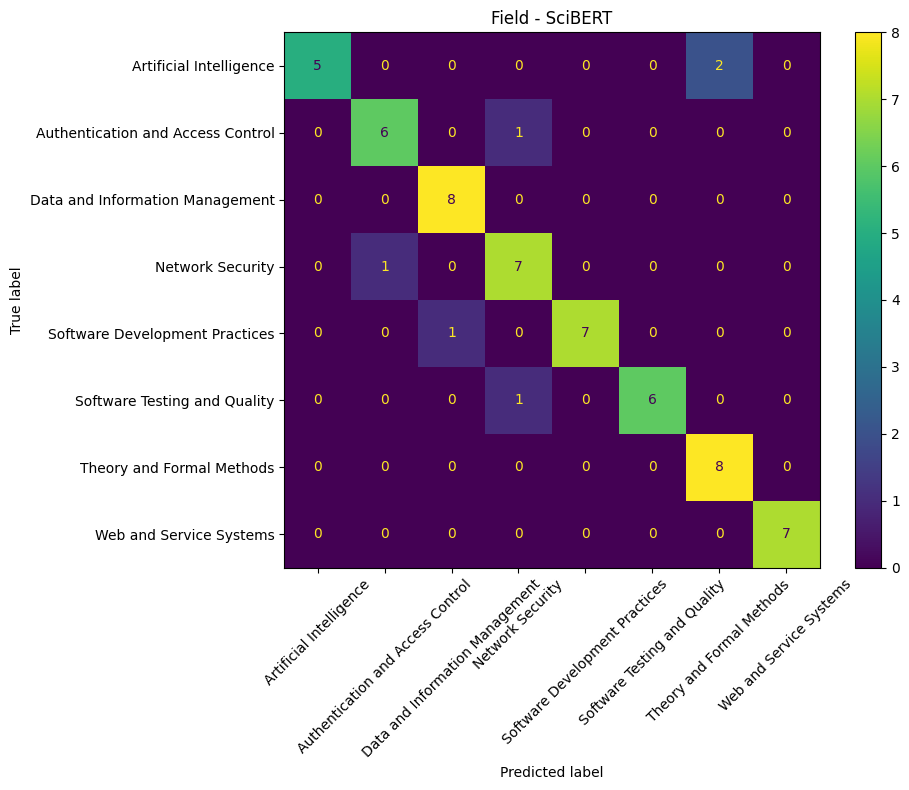

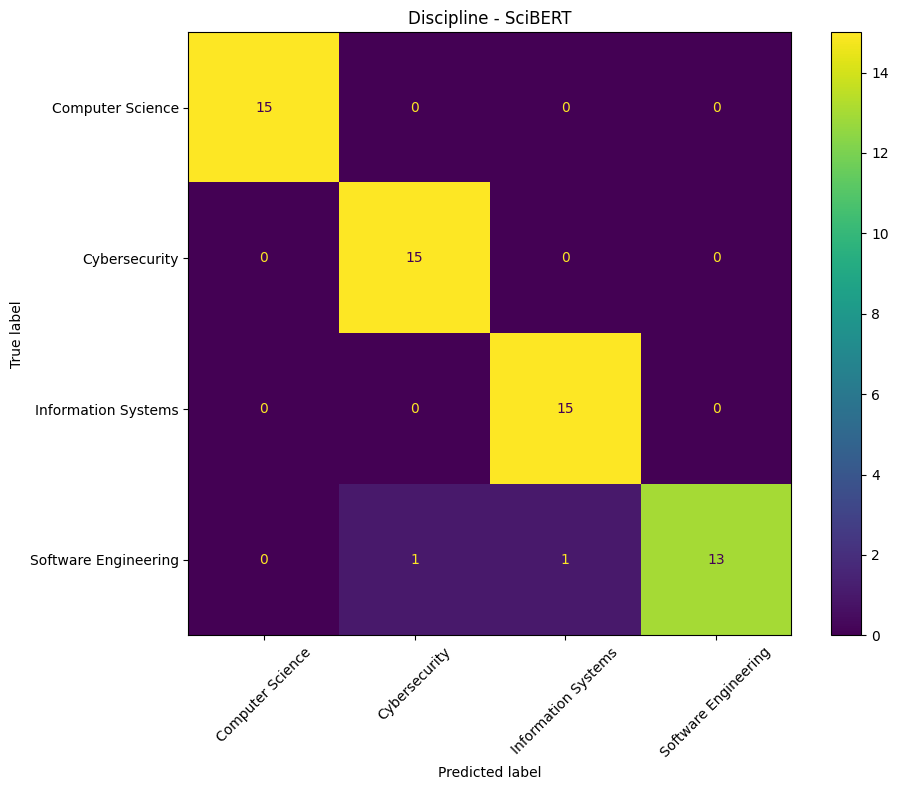

,epoch,train_loss,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,1.856050,0.616667,0.696212,0.616071,0.584747,0.587157
1,2,0.951739,0.850000,0.862550,0.852679,0.850697,0.849912
2,3,0.531252,0.866667,0.872272,0.870536,0.867349,0.865331


,task,selected epochs,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Field,3,0.900000,0.915476,0.897321,0.900060,0.899838
1,Discipline,3,0.966667,0.968750,0.966667,0.966014,0.966014


In [5]:
subject_train = subject_df[subject_df["split"] == "train"].copy()
subject_val = subject_df[subject_df["split"] == "validation"].copy()
subject_test = subject_df[subject_df["split"] == "test"].copy()

(
    field_epoch,
    field_history,
    field_classes,
    field_label_to_id,
    field_id_to_label,
) = select_epoch(
    subject_train,
    subject_val,
    "model_text",
    "field",
    FIELD_BATCH_SIZE,
)

subject_train_val = subject_df[
    subject_df["split"].isin(["train", "validation"])
].copy()

field_model, field_training = train_final(
    subject_train_val,
    "model_text",
    "field",
    field_classes,
    field_label_to_id,
    field_id_to_label,
    field_epoch,
    FIELD_BATCH_SIZE,
)

field_metrics, field_predictions = evaluate_task(
    "Field",
    field_model,
    subject_test,
    "model_text",
    "field",
    field_classes,
    field_label_to_id,
    field_id_to_label,
    FIELD_BATCH_SIZE,
)

true_disciplines = subject_test["discipline"].reset_index(drop=True)
predicted_disciplines = field_predictions["predicted_label"].map(field_to_discipline)

discipline_metrics = metric_summary(
    true_disciplines,
    predicted_disciplines,
)

discipline_predictions = pd.DataFrame({
    "paper_id": subject_test["paper_id"].values,
    "true_label": true_disciplines.values,
    "predicted_label": predicted_disciplines.values,
    "correct": true_disciplines.values == predicted_disciplines.values,
    "model": "SciBERT",
    "target": "Discipline",
    "split": "test",
})

discipline_predictions.to_csv(
    PREDICTION_DIR / "Discipline SciBERT Test Predictions.csv",
    index=False,
    encoding="utf-8",
)

discipline_classes = sorted(set(field_to_discipline.values()))

pd.DataFrame(
    classification_report(
        true_disciplines,
        predicted_disciplines,
        labels=discipline_classes,
        output_dict=True,
        zero_division=0,
    )
).transpose().to_csv(
    REPORT_DIR / "Discipline SciBERT Test Report.csv",
    encoding="utf-8",
)

save_confusion_matrix(
    true_disciplines,
    predicted_disciplines,
    discipline_classes,
    "Discipline - SciBERT",
    FIGURE_DIR / "Discipline SciBERT Confusion Matrix.png",
)

field_history.to_csv(
    RESULTS_DIR / "Field Validation History.csv",
    index=False,
    encoding="utf-8",
)

field_training.to_csv(
    RESULTS_DIR / "Field Training History.csv",
    index=False,
    encoding="utf-8",
)

field_summary = pd.DataFrame([
    {
        "task": "Field",
        "selected epochs": field_epoch,
        **field_metrics,
    },
    {
        "task": "Discipline",
        "selected epochs": field_epoch,
        **discipline_metrics,
    },
])

display(field_history)
display(field_summary)

## Methodology prediction

The Methodology model predicts one of six classes (from the masked title-and-abstract text). 

After held-out evaluation, the fitted model and tokenizer are saved for later inference on new publications.

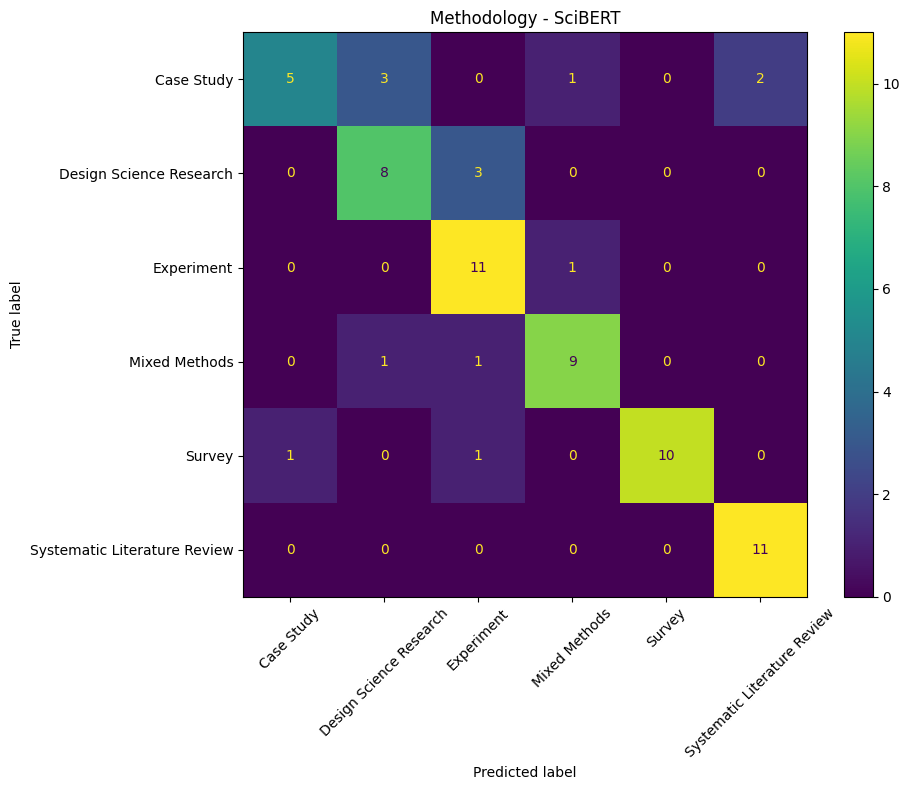

,epoch,train_loss,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,1.666810,0.611940,0.674525,0.609848,0.606131,0.606679
1,2,1.050709,0.761194,0.765657,0.762626,0.757915,0.756986
2,3,0.708661,0.805970,0.837607,0.806818,0.793181,0.792536


,task,selected epochs,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Methodology,3,0.794118,0.808639,0.791667,0.78559,0.787408


In [6]:
method_train = method_df[method_df["split"] == "train"].copy()
method_val = method_df[method_df["split"] == "validation"].copy()
method_test = method_df[method_df["split"] == "test"].copy()

(
    methodology_epoch,
    methodology_history,
    methodology_classes,
    methodology_label_to_id,
    methodology_id_to_label,
) = select_epoch(
    method_train,
    method_val,
    "methodology_text",
    "methodology",
    METHODOLOGY_BATCH_SIZE,
)

method_train_val = method_df[
    method_df["split"].isin(["train", "validation"])
].copy()

methodology_model, methodology_training = train_final(
    method_train_val,
    "methodology_text",
    "methodology",
    methodology_classes,
    methodology_label_to_id,
    methodology_id_to_label,
    methodology_epoch,
    METHODOLOGY_BATCH_SIZE,
)

methodology_metrics, methodology_predictions = evaluate_task(
    "Methodology",
    methodology_model,
    method_test,
    "methodology_text",
    "methodology",
    methodology_classes,
    methodology_label_to_id,
    methodology_id_to_label,
    METHODOLOGY_BATCH_SIZE,
)

methodology_history.to_csv(
    RESULTS_DIR / "Methodology Validation History.csv",
    index=False,
    encoding="utf-8",
)

methodology_training.to_csv(
    RESULTS_DIR / "Methodology Training History.csv",
    index=False,
    encoding="utf-8",
)

field_model_dir = MODEL_DIR / "Field"
methodology_model_dir = MODEL_DIR / "Methodology"

field_model_dir.mkdir(parents=True, exist_ok=True)
methodology_model_dir.mkdir(parents=True, exist_ok=True)

field_model.save_pretrained(
    field_model_dir,
    safe_serialization=True,
)

tokenizer.save_pretrained(field_model_dir)

methodology_model.save_pretrained(
    methodology_model_dir,
    safe_serialization=True,
)

tokenizer.save_pretrained(methodology_model_dir)

settings = {
    "checkpoint": SCIBERT_CHECKPOINT,
    "maximum_length": MAX_LENGTH,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "field_batch_size": FIELD_BATCH_SIZE,
    "methodology_batch_size": METHODOLOGY_BATCH_SIZE,
    "random_state": RANDOM_STATE,
    "field_epochs": field_epoch,
    "methodology_epochs": methodology_epoch,
}

with (MODEL_DIR / "SciBERT Model Settings.json").open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(settings, f, indent=2)

methodology_summary = pd.DataFrame([
    {
        "task": "Methodology",
        "selected epochs": methodology_epoch,
        **methodology_metrics,
    }
])

display(methodology_history)
display(methodology_summary)

## Comparing classical and SciBERT results

The saved classical test results are combined with the SciBERT results here. 

Field and derived Discipline are evaluated on the Subject test set. 

Methodology uses its separate test set. 

Discipline remains a mapped result.

In [7]:
classical_path = (
    Path("Results")
    / "Classical"
    / "Classical Test Results.csv"
)

if not classical_path.exists():
    raise FileNotFoundError(classical_path)

classical_results = pd.read_csv(classical_path)

scibert_results = pd.DataFrame([
    {
        "target": "Field",
        "model": "SciBERT",
        **field_metrics,
    },
    {
        "target": "Discipline",
        "model": "SciBERT",
        **discipline_metrics,
    },
    {
        "target": "Methodology",
        "model": "SciBERT",
        **methodology_metrics,
    },
])

scibert_results.to_csv(
    RESULTS_DIR / "SciBERT Test Results.csv",
    index=False,
    encoding="utf-8",
)

model_comparison = pd.concat(
    [
        classical_results,
        scibert_results,
    ],
    ignore_index=True,
).sort_values(
    ["target", "macro_f1"],
    ascending=[True, False],
)

model_comparison.to_csv(
    RESULTS_DIR / "Model Comparison.csv",
    index=False,
    encoding="utf-8",
)

display(model_comparison)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,target
10,SciBERT,0.966667,0.968750,0.966667,0.966014,0.966014,Discipline
3,Logistic Regression,0.816667,0.822371,0.816667,0.813141,0.813141,Discipline
4,Naive Bayes,0.816667,0.812449,0.816667,0.812279,0.812279,Discipline
5,Dummy,0.250000,0.062500,0.250000,0.100000,0.100000,Discipline
9,SciBERT,0.900000,0.915476,0.897321,0.900060,0.899838,Field
0,Logistic Regression,0.683333,0.691766,0.678571,0.676447,0.680555,Field
1,Naive Bayes,0.650000,0.650050,0.647321,0.645455,0.648888,Field
2,Dummy,0.116667,0.014583,0.125000,0.026119,0.024378,Field
11,SciBERT,0.794118,0.808639,0.791667,0.785590,0.787408,Methodology
6,Logistic Regression,0.750000,0.773718,0.752525,0.746041,0.744796,Methodology


## Effect of title and abstract input

This experiment tests how Methodology performance changes as the input changes (title-only, abstract-only and combined title-and-abstract). 

All conditions use the same saved partitions and masking rules. 

Each reduced-input SciBERT condition selects its own training duration, from validation performance. 

The combined result comes from the main Methodology run above.

In [8]:
method_df["masked_title"] = method_df["title"].apply(mask_methodology)
method_df["masked_abstract"] = method_df["abstract"].apply(mask_methodology)

experiment_train = method_df[method_df["split"] == "train"].copy()
experiment_val = method_df[method_df["split"] == "validation"].copy()
experiment_test = method_df[method_df["split"] == "test"].copy()
experiment_train_val = method_df[
    method_df["split"].isin(["train", "validation"])
].copy()


def make_lr():
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.98,
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                C=1.0,
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ])


experiment_rows = []

for input_name, text_column in [
    ("Title only", "masked_title"),
    ("Abstract only", "masked_abstract"),
    ("Title and abstract", "methodology_text"),
]:
    validation_model = make_lr()
    validation_model.fit(
        experiment_train[text_column],
        experiment_train["methodology"],
    )

    validation_predictions = validation_model.predict(
        experiment_val[text_column]
    )

    validation_metrics = metric_summary(
        experiment_val["methodology"],
        validation_predictions,
    )

    final_model = make_lr()
    final_model.fit(
        experiment_train_val[text_column],
        experiment_train_val["methodology"],
    )

    test_predictions = final_model.predict(
        experiment_test[text_column]
    )

    test_metrics = metric_summary(
        experiment_test["methodology"],
        test_predictions,
    )

    experiment_rows.append({
        "model": "Logistic Regression",
        "input": input_name,
        "validation_accuracy": validation_metrics["accuracy"],
        "validation_macro_f1": validation_metrics["macro_f1"],
        **test_metrics,
    })


def run_scibert_input(text_column, input_name):
    (
        best_epoch,
        history,
        classes,
        label_to_id,
        id_to_label,
    ) = select_epoch(
        experiment_train,
        experiment_val,
        text_column,
        "methodology",
        METHODOLOGY_BATCH_SIZE,
    )

    best_validation = (
        history
        .sort_values(
            ["macro_f1", "accuracy", "epoch"],
            ascending=[False, False, True],
        )
        .iloc[0]
    )

    final_model, _ = train_final(
        experiment_train_val,
        text_column,
        "methodology",
        classes,
        label_to_id,
        id_to_label,
        best_epoch,
        METHODOLOGY_BATCH_SIZE,
    )

    loader = make_loader(
        experiment_test,
        text_column,
        "methodology",
        label_to_id,
        False,
        METHODOLOGY_BATCH_SIZE,
    )

    y_true, y_pred, _ = predict(
        final_model,
        loader,
        id_to_label,
    )

    result = {
        "model": "SciBERT",
        "input": input_name,
        "selected_epochs": best_epoch,
        "validation_accuracy": float(best_validation["accuracy"]),
        "validation_macro_f1": float(best_validation["macro_f1"]),
        **metric_summary(y_true, y_pred),
    }

    del final_model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return result, history


experiment_history = []

for input_name, text_column in [
    ("Title only", "masked_title"),
    ("Abstract only", "masked_abstract"),
]:
    result, history = run_scibert_input(
        text_column,
        input_name,
    )

    experiment_rows.append(result)

    history = history.copy()
    history.insert(0, "input", input_name)
    experiment_history.append(history)

combined_validation = (
    methodology_history
    .sort_values(
        ["macro_f1", "accuracy", "epoch"],
        ascending=[False, False, True],
    )
    .iloc[0]
)

experiment_rows.append({
    "model": "SciBERT",
    "input": "Title and abstract",
    "selected_epochs": methodology_epoch,
    "validation_accuracy": float(combined_validation["accuracy"]),
    "validation_macro_f1": float(combined_validation["macro_f1"]),
    **methodology_metrics,
})

combined_history = methodology_history.copy()
combined_history.insert(0, "input", "Title and abstract")
experiment_history.append(combined_history)

input_experiment = pd.DataFrame(experiment_rows)

input_experiment.to_csv(
    RESULTS_DIR / "Methodology Input Experiment.csv",
    index=False,
    encoding="utf-8",
)

pd.concat(
    experiment_history,
    ignore_index=True,
).to_csv(
    RESULTS_DIR / "Methodology Input Experiment Validation.csv",
    index=False,
    encoding="utf-8",
)

display(
    input_experiment.sort_values(
        ["model", "macro_f1"],
        ascending=[True, False],
    )
)

,model,input,validation_accuracy,validation_macro_f1,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,selected_epochs
1,Logistic Regression,Abstract only,0.761194,0.755029,0.764706,0.781654,0.766414,0.762486,0.762208,NaN
2,Logistic Regression,Title and abstract,0.746269,0.740772,0.750000,0.773718,0.752525,0.746041,0.744796,NaN
0,Logistic Regression,Title only,0.537313,0.529041,0.558824,0.550241,0.556818,0.548252,0.550329,NaN
5,SciBERT,Title and abstract,0.805970,0.793181,0.794118,0.808639,0.791667,0.785590,0.787408,3.0
4,SciBERT,Abstract only,0.731343,0.719594,0.720588,0.774074,0.718434,0.712665,0.713184,2.0
3,SciBERT,Title only,0.731343,0.730138,0.602941,0.599725,0.606061,0.592778,0.591275,3.0


## Methodology error comparison

The Logistic Regression and the SciBERT Methodology predictions are matched one-to-one by `paper_id`. 

The outputs show: 
- where both models agree
- where only one model is correct
- how the errors are distributed in the true Methodology classes

In [9]:
lr_prediction_path = (
    Path("Results")
    / "Classical"
    / "Predictions"
    / "Methodology Logistic Regression Test Predictions.csv"
)

if not lr_prediction_path.exists():
    raise FileNotFoundError(lr_prediction_path)

lr_predictions = pd.read_csv(lr_prediction_path)
lr_predictions["paper_id"] = lr_predictions["paper_id"].astype(str)

sb_predictions = methodology_predictions.copy()
sb_predictions["paper_id"] = sb_predictions["paper_id"].astype(str)

comparison = (
    lr_predictions[
        [
            "paper_id",
            "true_label",
            "predicted_label",
            "confidence",
            "correct",
        ]
    ]
    .rename(columns={
        "predicted_label": "lr_prediction",
        "confidence": "lr_confidence",
        "correct": "lr_correct",
    })
    .merge(
        sb_predictions[
            [
                "paper_id",
                "predicted_label",
                "confidence",
                "correct",
            ]
        ].rename(columns={
            "predicted_label": "scibert_prediction",
            "confidence": "scibert_confidence",
            "correct": "scibert_correct",
        }),
        on="paper_id",
        validate="one_to_one",
    )
    .merge(
        method_df[
            [
                "paper_id",
                "title",
                "abstract",
                "methodology_text",
            ]
        ],
        on="paper_id",
        validate="one_to_one",
    )
)

comparison["group"] = np.select(
    [
        comparison["lr_correct"] & comparison["scibert_correct"],
        ~comparison["lr_correct"] & comparison["scibert_correct"],
        comparison["lr_correct"] & ~comparison["scibert_correct"],
    ],
    [
        "both correct",
        "SciBERT only",
        "Logistic Regression only",
    ],
    default="both wrong",
)

overlap = (
    comparison["group"]
    .value_counts()
    .rename_axis("result")
    .reset_index(name="papers")
)

error_review = comparison[
    comparison["group"] != "both correct"
].copy()

class_error_rows = []

for model_name, prediction_column in [
    ("Logistic Regression", "lr_prediction"),
    ("SciBERT", "scibert_prediction"),
]:
    temp = comparison.copy()
    temp["error"] = temp[prediction_column] != temp["true_label"]

    class_errors = (
        temp.groupby("true_label")
        .agg(
            test_papers=("paper_id", "size"),
            errors=("error", "sum"),
        )
        .reset_index()
    )

    class_errors["error_rate"] = (
        class_errors["errors"]
        / class_errors["test_papers"]
    )

    class_errors.insert(0, "model", model_name)
    class_error_rows.append(class_errors)

class_error_summary = pd.concat(
    class_error_rows,
    ignore_index=True,
)

overlap.to_csv(
    RESULTS_DIR / "Methodology Error Summary.csv",
    index=False,
    encoding="utf-8",
)

class_error_summary.to_csv(
    RESULTS_DIR / "Methodology Class Errors.csv",
    index=False,
    encoding="utf-8",
)

error_review.to_csv(
    RESULTS_DIR / "Methodology Error Review.csv",
    index=False,
    encoding="utf-8",
)

display(overlap)
display(class_error_summary)
display(
    error_review[
        [
            "paper_id",
            "true_label",
            "lr_prediction",
            "scibert_prediction",
            "group",
            "title",
        ]
    ]
)

,result,papers
0,both correct,47
1,both wrong,10
2,SciBERT only,7
3,Logistic Regression only,4


,model,true_label,test_papers,errors,error_rate
0,Logistic Regression,Case Study,11,4,0.363636
1,Logistic Regression,Design Science Research,11,3,0.272727
2,Logistic Regression,Experiment,12,2,0.166667
3,Logistic Regression,Mixed Methods,11,2,0.181818
4,Logistic Regression,Survey,12,6,0.500000
5,Logistic Regression,Systematic Literature Review,11,0,0.000000
6,SciBERT,Case Study,11,6,0.545455
7,SciBERT,Design Science Research,11,3,0.272727
8,SciBERT,Experiment,12,1,0.083333
9,SciBERT,Mixed Methods,11,2,0.181818


,paper_id,true_label,lr_prediction,scibert_prediction,group,title
0,W1967044255,Case Study,Case Study,Mixed Methods,Logistic Regression only,Towards an explanatory theory of motivation in...
1,W4236532781,Case Study,Experiment,Case Study,SciBERT only,User involvement in software evolution practic...
3,W2030164119,Case Study,Case Study,Systematic Literature Review,Logistic Regression only,A Case Study of the Introduction of Computer S...
6,W2891794946,Case Study,Experiment,Systematic Literature Review,both wrong,Machine learning research that matters for mus...
8,W3013504025,Case Study,Case Study,Design Science Research,Logistic Regression only,Towards a Model-Driven Product Line Engineerin...
9,W3136959127,Case Study,Design Science Research,Design Science Research,both wrong,Role of blockchain in HR's response to new-normal
10,W4378194664,Case Study,Mixed Methods,Design Science Research,both wrong,Enhancing STEM learning with ChatGPT and Bing ...
11,W2098684637,Design Science Research,Design Science Research,Experiment,Logistic Regression only,Mobile augmented reality for cultural heritage...
14,W3040693899,Design Science Research,Systematic Literature Review,Experiment,both wrong,A Design Science Research to Correct Inherent ...
20,W4387711869,Design Science Research,Case Study,Design Science Research,SciBERT only,Implementing Exploratory Testing in an Agile C...


## Predicting a new publication

This is a demonstration that uses a new title and abstract, outside the labelled test set. 

The final preprocessing and fitted models return Field/Discipline/Methodology together with the highest softmax score for each learned prediction.

(the scores are model outputs)

In [10]:
def combine_text(title, abstract):
    if not isinstance(title, str) or not isinstance(abstract, str):
        raise ValueError("Both title and abstract must be non-empty strings.")

    title = title.strip()
    abstract = abstract.strip()

    if not title or not abstract:
        raise ValueError("Both title and abstract must be non-empty strings.")

    return f"{title}. {abstract}"


@torch.no_grad()
def predict_text(text, model):
    model.eval()

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )

    encoded = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    probabilities = torch.softmax(
        model(**encoded).logits,
        dim=-1,
    )[0]

    confidence, predicted_id = probabilities.max(dim=0)
    predicted_id = int(predicted_id.cpu().item())

    return (
        model.config.id2label[predicted_id],
        float(confidence.cpu().item()),
    )


def classify_paper(title, abstract):
    text = combine_text(title, abstract)
    methodology_text = mask_methodology(
        f"{title.strip()}. {abstract.strip()}"
    )

    field, field_confidence = predict_text(
        text,
        field_model,
    )

    methodology, methodology_confidence = predict_text(
        methodology_text,
        methodology_model,
    )

    return {
        "discipline": field_to_discipline[field],
        "field": field,
        "field_confidence": field_confidence,
        "methodology": methodology,
        "methodology_confidence": methodology_confidence,
    }


demo_title = (
    "Evaluating a Federated Learning Framework "
    "for Detecting Network Intrusions"
)

demo_abstract = (
    "This paper presents a federated learning framework for network "
    "intrusion detection in distributed organisations. The system "
    "trains local classifiers without centralising traffic data. "
    "Its performance is measured on benchmark network-security data "
    "and compared with centrally trained baselines."
)

display(pd.DataFrame([
    classify_paper(
        demo_title,
        demo_abstract,
    )
]))

,discipline,field,field_confidence,methodology,methodology_confidence
0,Cybersecurity,Network Security,0.832278,Experiment,0.465583


## Batch prediction from CSV

The same prediction function can process a CSV containing `title` and `abstract` columns. 

The original columns are retained beside the predicted labels and model scores, the completed output is written to a new CSV.

In [11]:
def classify_csv(input_path, output_path):
    frame = pd.read_csv(input_path)

    if not {"title", "abstract"}.issubset(frame.columns):
        raise ValueError("The input file needs title and abstract columns.")

    predictions = [
        classify_paper(
            row["title"],
            row["abstract"],
        )
        for _, row in frame.iterrows()
    ]

    output = pd.concat(
        [
            frame.reset_index(drop=True),
            pd.DataFrame(predictions),
        ],
        axis=1,
    )

    output.to_csv(
        output_path,
        index=False,
        encoding="utf-8",
    )

    return output